In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [49]:
df = pd.read_csv('sample_data.csv')
df.head()

,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality,emotional_state,intensity
0,1,The ocean ambience helped me stop drifting and...,ocean,12,6.5,4,2,afternoon,mixed,calm_face,clear,focused,3
1,2,"I tried to relax during the forest ambience, y...",forest,35,6.0,2,4,evening,calm,tired_face,vague,restless,3
2,3,The forest session slowed my thoughts and I fe...,forest,3,NaN,2,1,night,overwhelmed,happy_face,clear,calm,3
3,4,"the mountain ambience was pleasant, though i c...",mountain,25,7.0,4,4,night,focused,calm_face,vague,neutral,1
4,5,"The rain session gave me a pause, but the pres...",rain,25,5.0,3,5,afternoon,NaN,tense_face,clear,overwhelmed,5


In [50]:
print("Shape : ", df.shape)
print("\nColumns : ", df.columns)

df.info()

Shape :  (1200, 13)

Columns :  Index(['id', 'journal_text', 'ambience_type', 'duration_min', 'sleep_hours',
       'energy_level', 'stress_level', 'time_of_day', 'previous_day_mood',
       'face_emotion_hint', 'reflection_quality', 'emotional_state',
       'intensity'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1200 non-null   int64  
 1   journal_text        1200 non-null   object 
 2   ambience_type       1200 non-null   object 
 3   duration_min        1200 non-null   int64  
 4   sleep_hours         1193 non-null   float64
 5   energy_level        1200 non-null   int64  
 6   stress_level        1200 non-null   int64  
 7   time_of_day         1200 non-null   object 
 8   previous_day_mood   1185 non-null   object 
 9   face_emotion_hint   1077 non-null   object 
 10  refl

In [51]:
df.isnull().sum()

id                      0
journal_text            0
ambience_type           0
duration_min            0
sleep_hours             7
energy_level            0
stress_level            0
time_of_day             0
previous_day_mood      15
face_emotion_hint     123
reflection_quality      0
emotional_state         0
intensity               0
dtype: int64

In [52]:
df['sleep_hours'] = df['sleep_hours'].fillna(df['sleep_hours'].median())
df['previous_day_mood'] = df['previous_day_mood'].fillna("unknown")
df = df.drop(columns=['face_emotion_hint'])

df.isnull().sum()




id                    0
journal_text          0
ambience_type         0
duration_min          0
sleep_hours           0
energy_level          0
stress_level          0
time_of_day           0
previous_day_mood     0
reflection_quality    0
emotional_state       0
intensity             0
dtype: int64

In [53]:
categorical_cols = [
    'ambience_type',
    'time_of_day',
    'previous_day_mood',
    'reflection_quality',
    'emotional_state'
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


ambience_type
ambience_type
ocean       268
mountain    252
forest      231
cafe        229
rain        220
Name: count, dtype: int64

time_of_day
time_of_day
afternoon        319
morning          302
night            286
evening          268
early_morning     25
Name: count, dtype: int64

previous_day_mood
previous_day_mood
mixed          213
restless       208
neutral        203
overwhelmed    202
calm           182
focused        177
unknown         15
Name: count, dtype: int64

reflection_quality
reflection_quality
clear         411
vague         400
conflicted    389
Name: count, dtype: int64

emotional_state
emotional_state
calm           216
restless       209
neutral        201
focused        193
mixed          191
overwhelmed    190
Name: count, dtype: int64


In [54]:
df['time_of_day'] = df['time_of_day'].replace({"early_morning":"morning"})
df['time_of_day'].value_counts()

time_of_day
morning      327
afternoon    319
night        286
evening      268
Name: count, dtype: int64

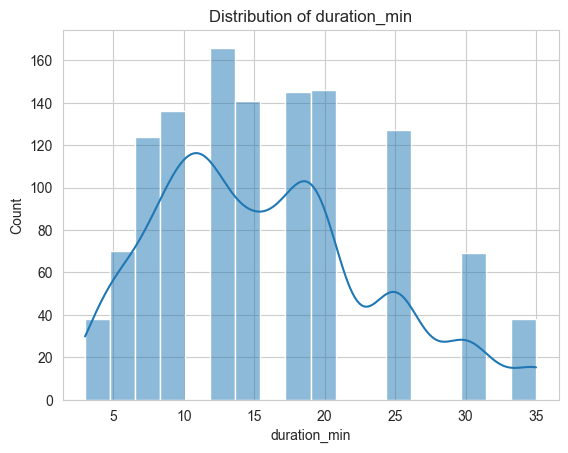

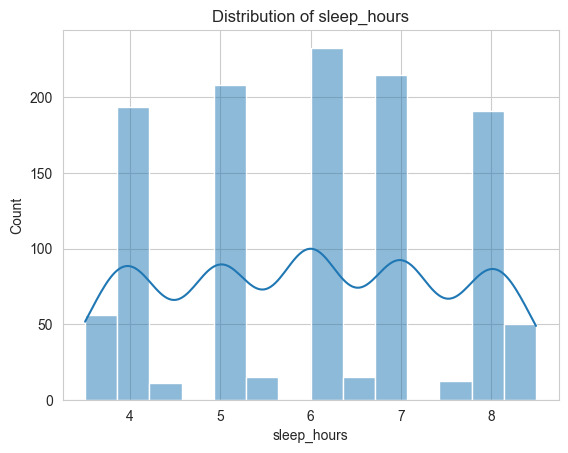

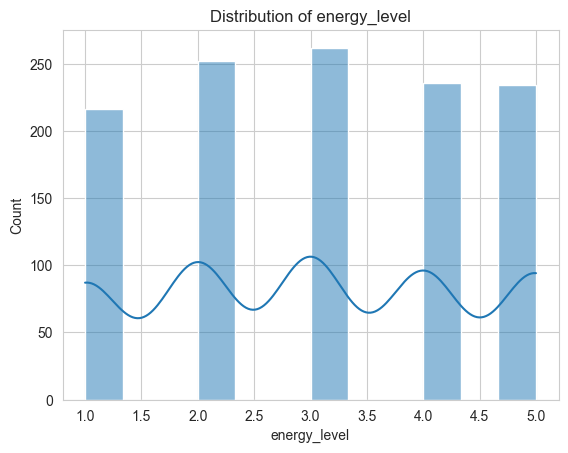

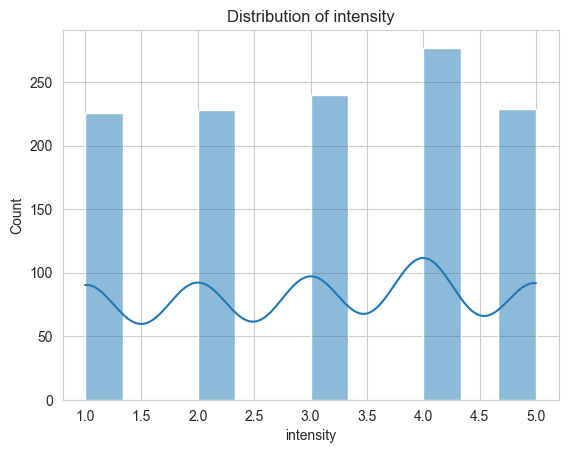

In [55]:
num_cols = [
    'duration_min',
    'sleep_hours',
    'energy_level',
    'intensity'
]

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

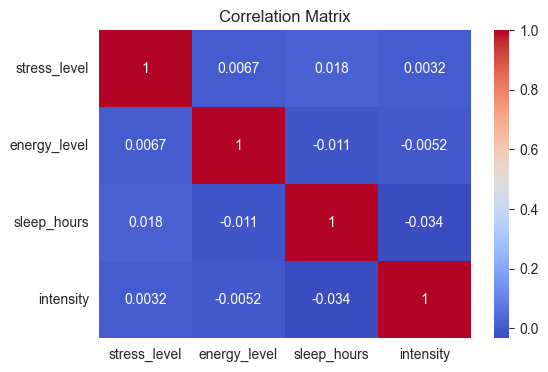

In [56]:
corr = df[['stress_level', 'energy_level', 'sleep_hours', 'intensity']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

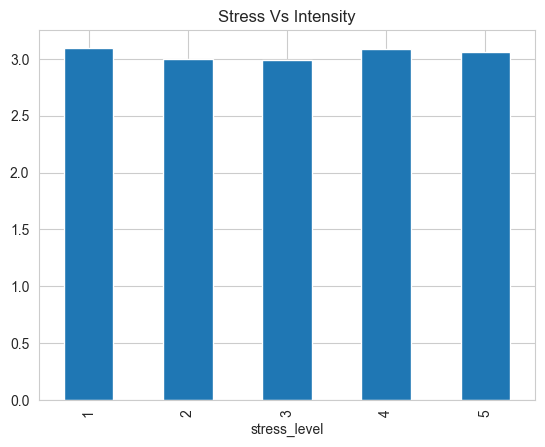

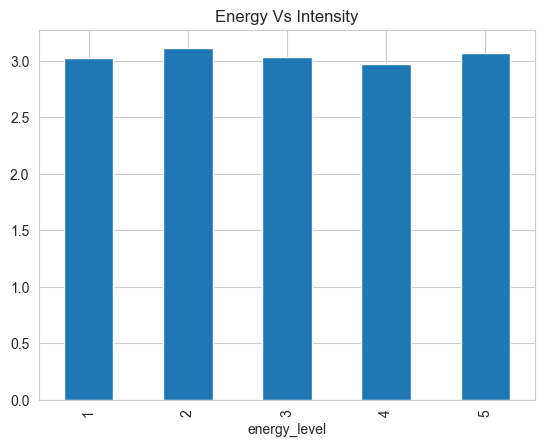

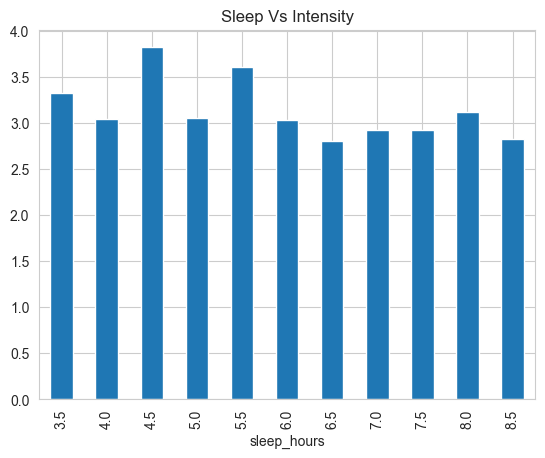

In [57]:
df.groupby('stress_level')['intensity'].mean().plot(kind='bar')
plt.title("Stress Vs Intensity")
plt.show()

df.groupby('energy_level')['intensity'].mean().plot(kind='bar')
plt.title("Energy Vs Intensity")
plt.show()

df.groupby('sleep_hours')['intensity'].mean().plot(kind='bar')
plt.title("Sleep Vs Intensity")
plt.show()



In [58]:
df[['journal_text', 'emotional_state', 'intensity']].sample(10)

,journal_text,emotional_state,intensity
1104,a little lighter,calm,1
506,kept thinking about work,calm,4
322,Strangely things felt more peaceful and I just...,calm,3
663,back to normal after,overwhelmed,1
1013,somehow i felt unable to stay with one thought...,restless,5
345,During the session my thoughts felt lighter bu...,calm,4
1017,kind of felt not bad but not clear either. i w...,mixed,5
434,For some reason I didn't notice strong emotion...,neutral,2
148,Strangely my thoughts became clearer which sur...,focused,2
1042,after the session i felt kind of blank. then m...,neutral,3


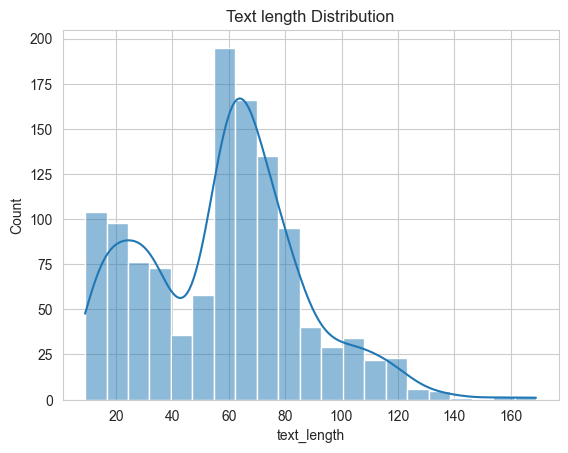

In [59]:
df['text_length'] = df['journal_text'].apply(len)
plt.figure()

sns.histplot(df['text_length'], kde=True)
plt.title("Text length Distribution")
plt.show()

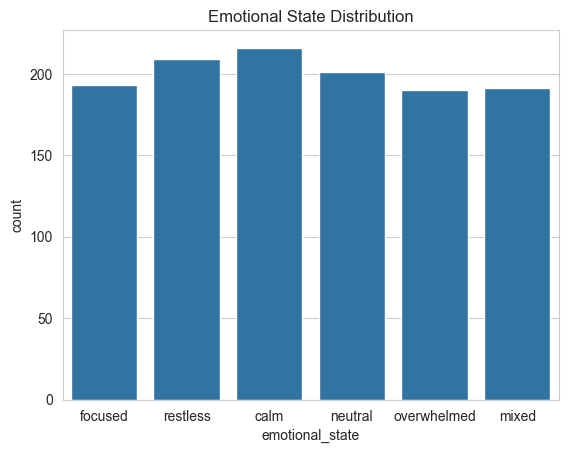

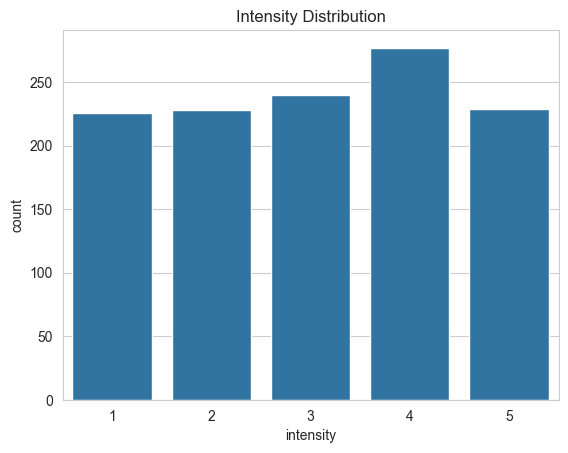

In [60]:
plt.figure()
sns.countplot(x='emotional_state', data=df)
plt.title("Emotional State Distribution")
plt.show()

plt.figure()
sns.countplot(x='intensity', data=df)
plt.title("Intensity Distribution")
plt.show()


In [61]:
df.sample(5)

,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,reflection_quality,emotional_state,intensity,text_length
248,249,"Honestly some moments felt peaceful, others no...",forest,20,6.0,1,3,evening,neutral,vague,mixed,2,72
22,23,"even after the forest track, i feel exhausted ...",forest,18,5.5,2,4,morning,focused,vague,overwhelmed,5,128
772,773,At first felt heavy.,forest,30,7.0,4,3,afternoon,neutral,clear,restless,2,20
1062,943,"somehow i felt drained and behind, but i was m...",ocean,35,7.0,3,1,night,restless,conflicted,overwhelmed,1,71
657,658,By teh end still anxious a bit.,cafe,25,5.0,5,1,afternoon,mixed,vague,focused,4,31
